In [1]:
import os
import sys
parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

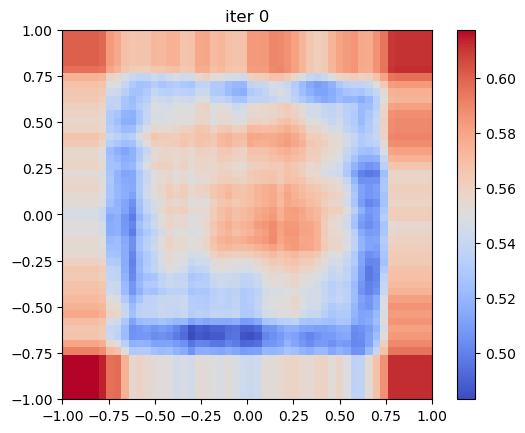

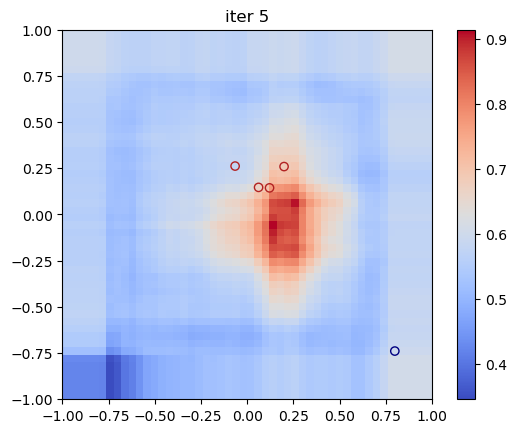

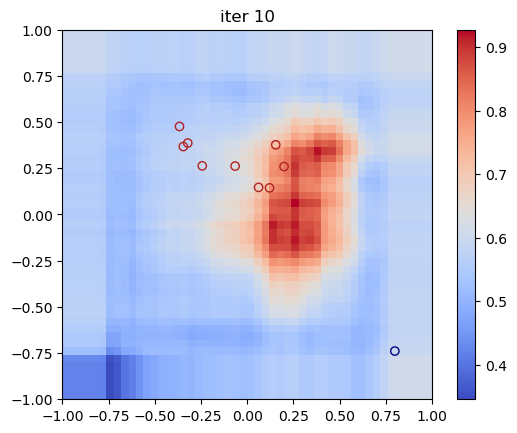

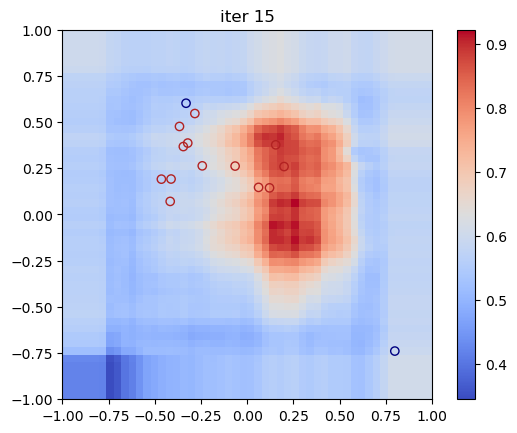

In [2]:
import datasets
from src.alif import Alif
from experiments.utils import run_sim

data, labels = datasets.load()
alif = Alif(parallel_jobs=8)
run_sim(
    model=alif, n_iter=20, data_train=data, labels_train=labels, show_heatmap_evol=True
);


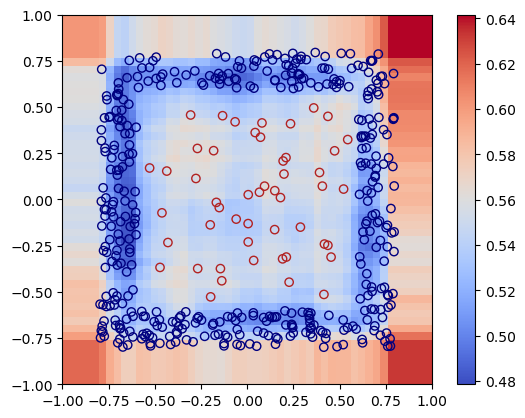

In [2]:
import datasets
from src.alif import Alif
from experiments.plotting import heatmap_2d

data, labels = datasets.load()
alif = Alif(parallel_jobs=8)
alif.fit(data)
heatmap_2d(
    alif, n_grid_points=50, marked_outliers=data[labels == 1], marked_inliers=data[labels == 0]
)


In [2]:
import datasets
from utils import run_sim
from src.alif import Alif

data, labels = datasets.load()

sim_results = run_sim(model=Alif(), n_iter=5, data_train=data, labels_train=labels)

fitting model


(0.0, 1.0)

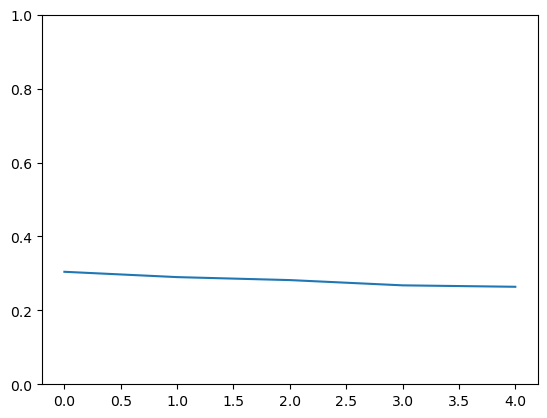

In [5]:
import numpy as np 
import matplotlib.pyplot as plt

ap = np.array([sim_results[f"AP_{iter}_queries"] for iter in range(5)])
plt.plot(ap)
plt.ylim(0, 1)

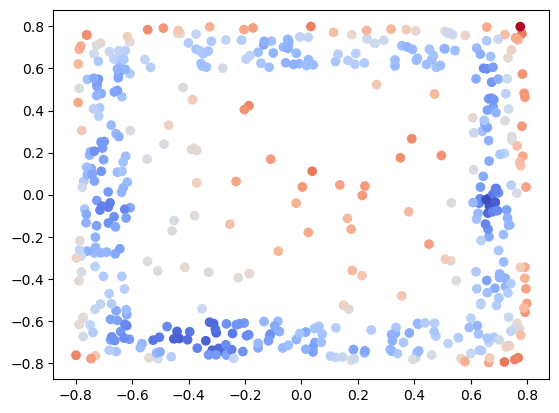

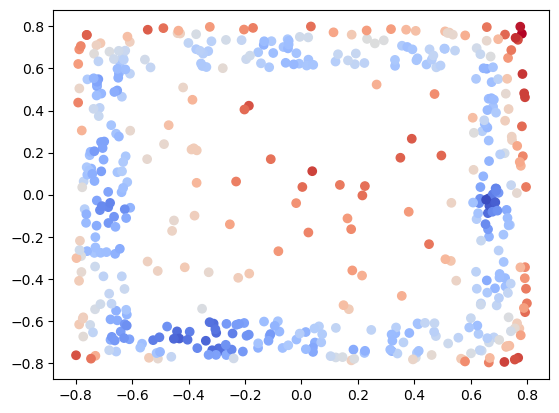

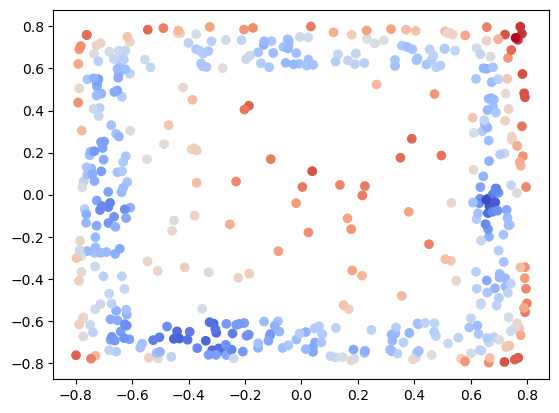

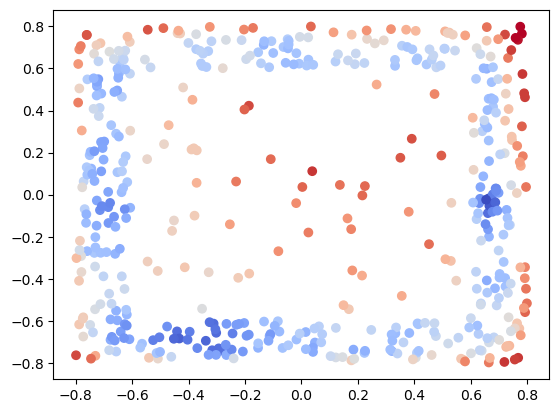

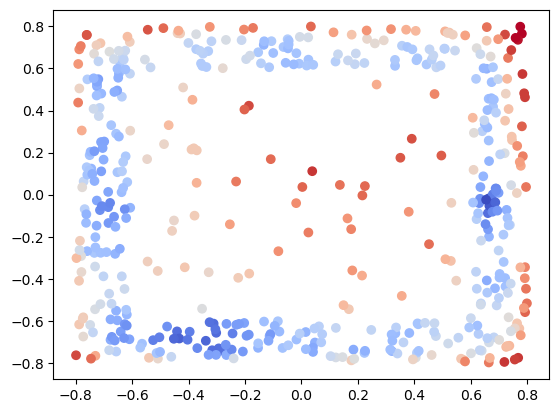

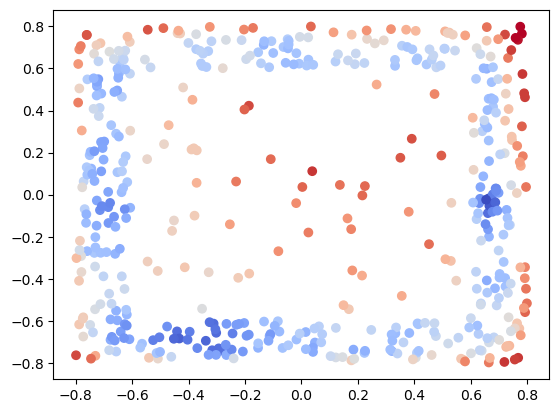

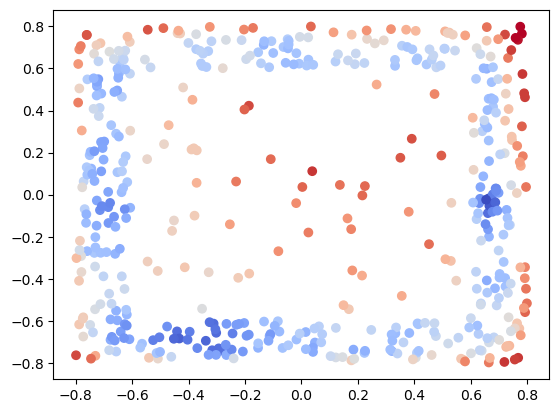

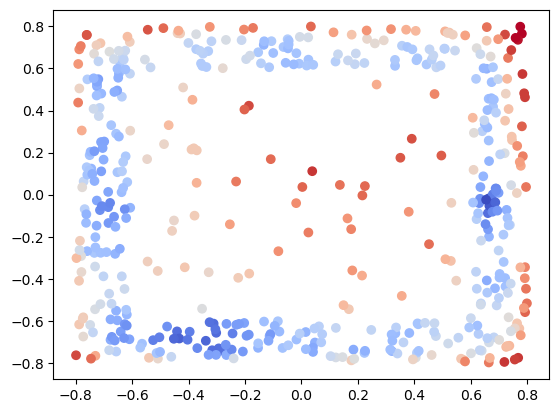

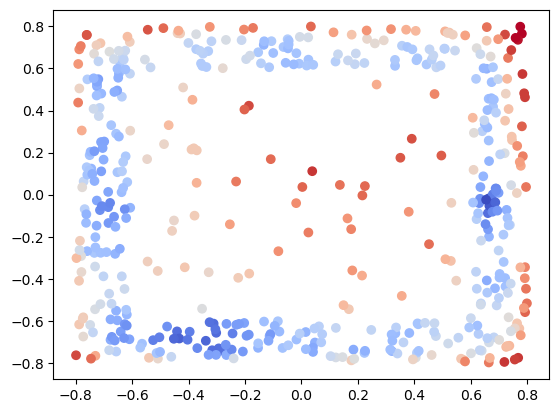

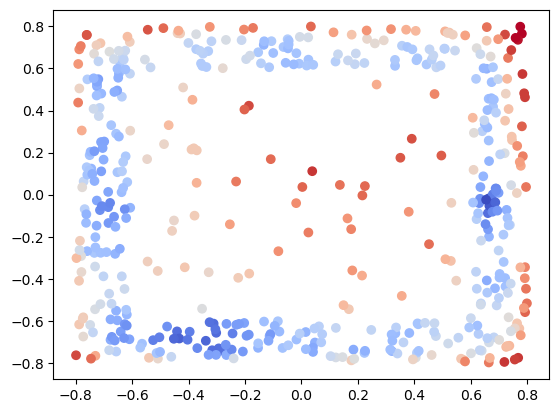

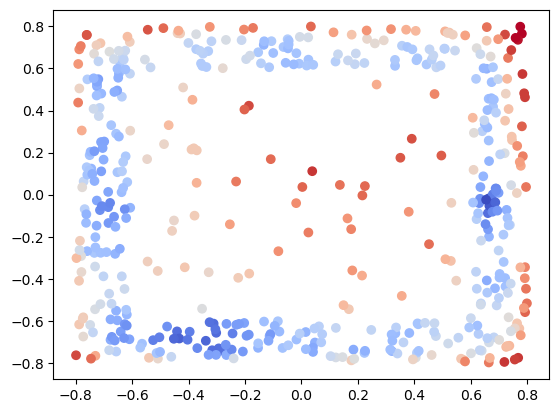

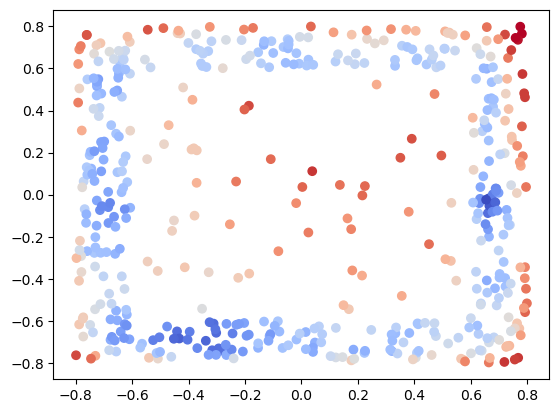

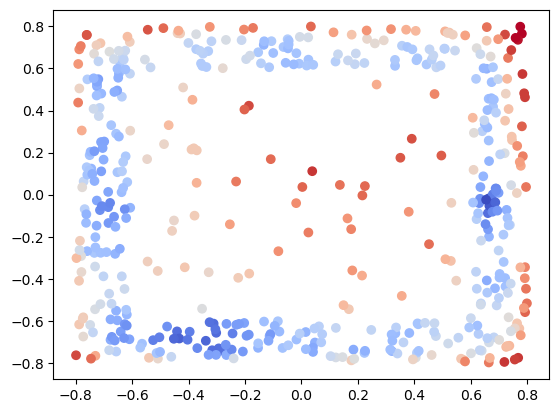

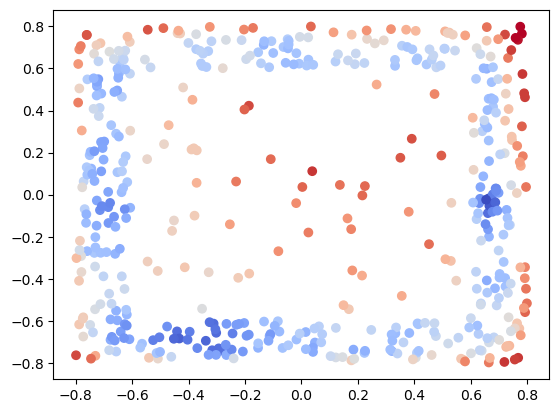

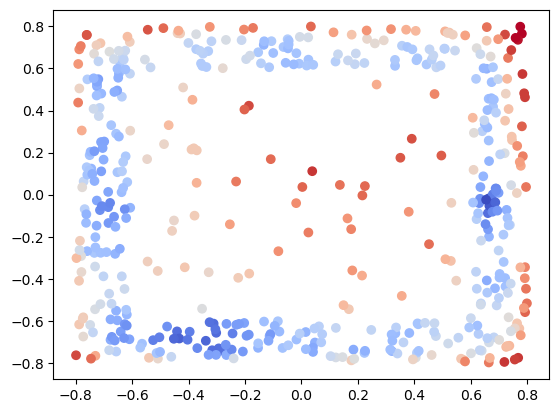

KeyError: 'scores_15_queries'

In [4]:
from sklearn.metrics import precision_recall_curve

for iter in range(30):
    labels = sim_results["true_labels"]
    scores = sim_results[f"scores_{iter}_queries"]
    
    precision, recall, _ = precision_recall_curve(labels, scores)
    #plt.plot(recall, precision, label=f"iter {iter}")   
    
    plt.figure()
    plt.scatter(data[:, 0], data[:, 1], c=scores, cmap="coolwarm")
    plt.show()    